# Introduction

### Load in trained model

In [5]:
# Import necessary libraries
import pathlib
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import zscore

# Define utility functions and model classes (copied from your script)
def load_ucr_txt(path: pathlib.Path) -> tuple[np.ndarray, np.ndarray]:
    """
    Loads a UCR .txt file irrespective of whether it is comma- or
    whitespace-separated.  Returns:
        X  – (N, L) float32
        y  – (N,)   int64   (converts labels to 0 … C-1 internally)
    """
    series, labels = [], []
    with open(path, "r") as f:
        for ln in f:
            parts = ln.replace('\t', ' ').strip().split(',')
            if len(parts) == 1:
                parts = [p for p in ln.split() if p]
            label_str, *values = parts
            labels.append(int(float(label_str)))
            series.append([float(v) for v in values])
    X = np.asarray(series, dtype=np.float32)
    y_raw = np.asarray(labels, dtype=np.int64)
    uniq = {lab: i for i, lab in enumerate(sorted(set(y_raw)))}
    y = np.vectorize(uniq.get)(y_raw).astype(np.int64)
    return X, y

class Encoder1D(nn.Module):
    """Very small 1-D CNN encoder (similar to FCN-Baseline)."""
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(128, out_dim), nn.ReLU()
        )

    def forward(self, x):
        return self.net(x.unsqueeze(1))

class SoftmaxHead(nn.Module):
    def __init__(self, in_dim, n_cls):
        super().__init__()
        self.logits = nn.Linear(in_dim, n_cls)

    def forward(self, h):
        return self.logits(h)

class HarmaxHead(nn.Module):
    """Learnable class centres  C∈ ℝ^{nCls×d}; p_i ∝ 1/‖h-C_i‖^n"""
    def __init__(self, in_dim, n_cls, n_exp=None):
        super().__init__()
        self.centres = nn.Parameter(torch.randn(n_cls, in_dim)/np.sqrt(in_dim))
        self.n_exp = n_exp or int(np.sqrt(in_dim))

    def probs(self, h):
        d = torch.cdist(h, self.centres) + 1e-8
        inv = d.pow(-self.n_exp)
        return inv / inv.sum(dim=1, keepdim=True)

    def forward(self, h):
        return self.probs(h)

class Wrapper(nn.Module):
    def __init__(self, encoder, head, is_harmax=False):
        super().__init__()
        self.encoder, self.head, self.is_harmax = encoder, head, is_harmax

# Load the ECG200 dataset to determine n_cls
data_dir = pathlib.Path('data')
Xtr, ytr = load_ucr_txt(data_dir / 'ECG200_TRAIN.txt')
Xte, yte = load_ucr_txt(data_dir / 'ECG200_TEST.txt')
Xtr, Xte = zscore(Xtr), zscore(Xte)

n_cls = len(np.unique(ytr))
print(f"ECG200: train {Xtr.shape}, test {Xte.shape}, classes={n_cls}")

# Create test DataLoader
te_dl = DataLoader(TensorDataset(torch.tensor(Xte), torch.tensor(yte)), batch_size=32)

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Recreate the models
out_dim = 64  # Same as in your script
softmax_model = Wrapper(
    encoder=Encoder1D(out_dim),
    head=SoftmaxHead(out_dim, n_cls),
    is_harmax=False
)
n_exp = 8  # Default n_exp = sqrt(64) = 8, adjust if you used a different value
harmax_model = Wrapper(
    encoder=Encoder1D(out_dim),
    head=HarmaxHead(out_dim, n_cls, n_exp=n_exp),
    is_harmax=True
)

# Load the saved state dictionaries
model_dir = pathlib.Path('models')
softmax_model.load_state_dict(torch.load(model_dir / 'ecg200_softmax.pt'))
harmax_model.load_state_dict(torch.load(model_dir / f'ecg200_harmax_n{n_exp}.pt'))

# Move models to device
softmax_model.to(device)
harmax_model.to(device)

# Set models to evaluation mode
softmax_model.eval()
harmax_model.eval()

# Example: Evaluate on test set
def evaluate(model, is_harmax, loader, device):
    total, correct = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            h = model.encoder(X)
            if is_harmax:
                probs = model.head(h)
                pred = probs.argmax(1)
            else:
                logits = model.head(h)
                pred = logits.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

softmax_acc = evaluate(softmax_model, False, te_dl, device)
harmax_acc = evaluate(harmax_model, True, te_dl, device)

print(f"Test Accuracy - Softmax: {softmax_acc*100:.1f}%")
print(f"Test Accuracy - Harmax (n={n_exp}): {harmax_acc*100:.1f}%")

# Models are now loaded and ready for further analysis!

ECG200: train (100, 96), test (100, 96), classes=2
Test Accuracy - Softmax: 82.0%
Test Accuracy - Harmax (n=8): 82.0%


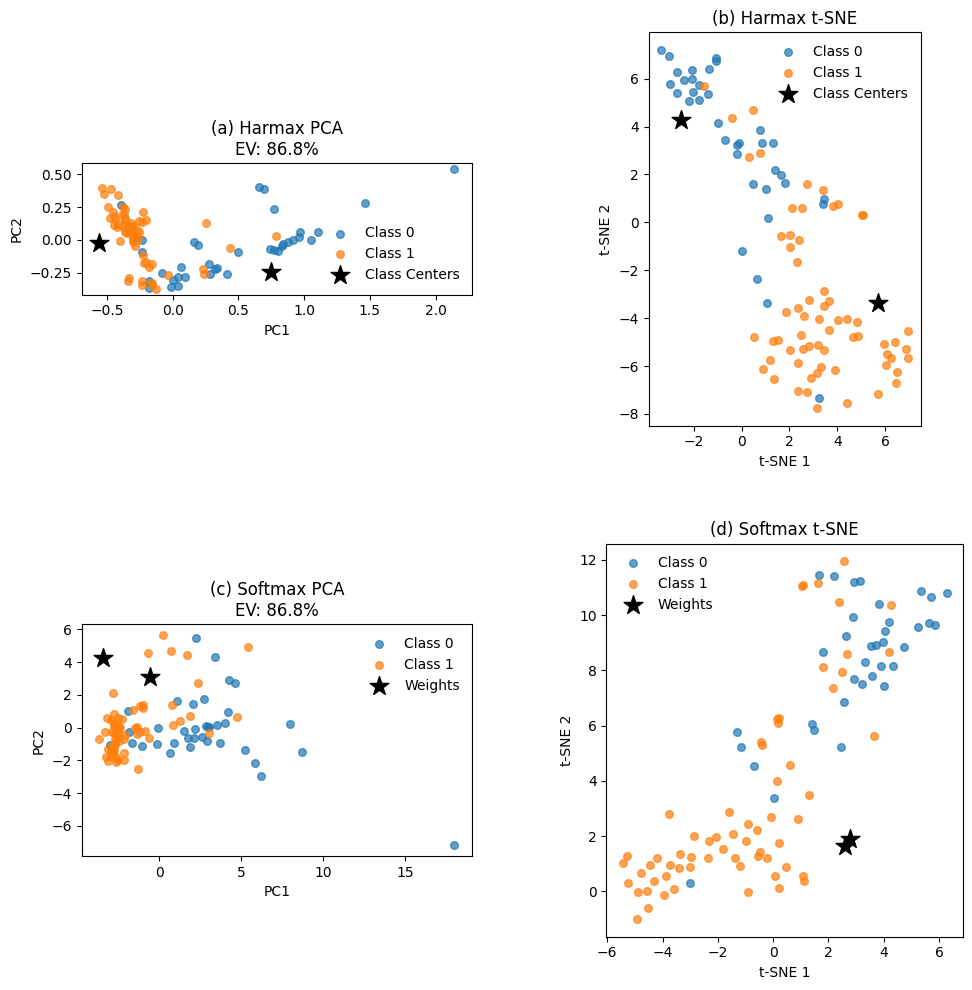

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Function to extract embeddings (already defined)
def get_embeddings(model, loader, device):
    model.eval()
    embeddings = []
    labels = []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            h = model.encoder(X)
            embeddings.append(h.cpu())
            labels.append(y)
    embeddings = torch.cat(embeddings, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()
    return embeddings, labels

# Extract embeddings for both models
harmax_embeddings, harmax_labels = get_embeddings(harmax_model, te_dl, device)
softmax_embeddings, softmax_labels = get_embeddings(softmax_model, te_dl, device)

# Verify that labels are the same
assert np.array_equal(harmax_labels, softmax_labels), "Labels should be the same for both models"
labels = harmax_labels

# Get class centers and weights
harmax_centres = harmax_model.head.centres.detach().cpu().numpy()  # (n_cls, 64)
softmax_weights = softmax_model.head.logits.weight.detach().cpu().numpy()  # (n_cls, 64)

# Create a 2x2 subplot with equal physical sizes
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# --- Top Row: Harmax Embeddings ---
# (a) PCA for Harmax
pca = PCA(n_components=2)
harmax_pca = pca.fit_transform(harmax_embeddings)
harmax_explained_variance = pca.explained_variance_ratio_.sum() * 100
harmax_centres_pca = pca.transform(harmax_centres)

# Plot PCA for Harmax
for cls in np.unique(labels):
    mask = labels == cls
    axs[0, 0].scatter(harmax_pca[mask, 0], harmax_pca[mask, 1], 
                      label=f'Class {cls}', s=30, alpha=0.7)
axs[0, 0].scatter(harmax_centres_pca[:, 0], harmax_centres_pca[:, 1], 
                  c='black', marker='*', s=200, label='Class Centers')
axs[0, 0].set_title(f'(a) Harmax PCA\nEV: {harmax_explained_variance:.1f}%')
axs[0, 0].set_xlabel('PC1')
axs[0, 0].set_ylabel('PC2')
axs[0, 0].legend()
axs[0, 0].set_aspect('equal')

# (b) t-SNE for Harmax
combined_harmax = np.vstack((harmax_embeddings, harmax_centres))
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
combined_harmax_tsne = tsne.fit_transform(combined_harmax)
harmax_tsne = combined_harmax_tsne[:len(harmax_embeddings)]
harmax_centres_tsne = combined_harmax_tsne[len(harmax_embeddings):]

# Plot t-SNE for Harmax
for cls in np.unique(labels):
    mask = labels == cls
    axs[0, 1].scatter(harmax_tsne[mask, 0], harmax_tsne[mask, 1], 
                      label=f'Class {cls}', s=30, alpha=0.7)
axs[0, 1].scatter(harmax_centres_tsne[:, 0], harmax_centres_tsne[:, 1], 
                  c='black', marker='*', s=200, label='Class Centers')
axs[0, 1].set_title('(b) Harmax t-SNE')
axs[0, 1].set_xlabel('t-SNE 1')
axs[0, 1].set_ylabel('t-SNE 2')
axs[0, 1].legend()
axs[0, 1].set_aspect('equal')

# --- Bottom Row: Softmax Embeddings ---
# (c) PCA for Softmax
pca = PCA(n_components=2)
softmax_pca = pca.fit_transform(softmax_embeddings)
softmax_explained_variance = pca.explained_variance_ratio_.sum() * 100
softmax_weights_pca = pca.transform(softmax_weights)

# Plot PCA for Softmax
for cls in np.unique(labels):
    mask = labels == cls
    axs[1, 0].scatter(softmax_pca[mask, 0], softmax_pca[mask, 1], 
                      label=f'Class {cls}', s=30, alpha=0.7)
axs[1, 0].scatter(softmax_weights_pca[:, 0], softmax_weights_pca[:, 1], 
                  c='black', marker='*', s=200, label='Weights')
axs[1, 0].set_title(f'(c) Softmax PCA\nEV: {softmax_explained_variance:.1f}%')
axs[1, 0].set_xlabel('PC1')
axs[1, 0].set_ylabel('PC2')
axs[1, 0].legend()
axs[1, 0].set_aspect('equal')

# (d) t-SNE for Softmax
combined_softmax = np.vstack((softmax_embeddings, softmax_weights))
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
combined_softmax_tsne = tsne.fit_transform(combined_softmax)
softmax_tsne = combined_softmax_tsne[:len(softmax_embeddings)]
softmax_weights_tsne = combined_softmax_tsne[len(softmax_embeddings):]

# Plot t-SNE for Softmax
for cls in np.unique(labels):
    mask = labels == cls
    axs[1, 1].scatter(softmax_tsne[mask, 0], softmax_tsne[mask, 1], 
                      label=f'Class {cls}', s=30, alpha=0.7)
axs[1, 1].scatter(softmax_weights_tsne[:, 0], softmax_weights_tsne[:, 1], 
                  c='black', marker='*', s=200, label='Weights')
axs[1, 1].set_title('(d) Softmax t-SNE')
axs[1, 1].set_xlabel('t-SNE 1')
axs[1, 1].set_ylabel('t-SNE 2')
axs[1, 1].legend()
axs[1, 1].set_aspect('equal')

# Adjust layout to ensure equal physical sizes
plt.tight_layout()

# Fine-tune the spacing to ensure the panels have the same physical size
plt.subplots_adjust(wspace=0.3, hspace=0.3)

# Save the plot
plt.savefig('figures/ecg200_embeddings_comparison_equal_sizes.png', dpi=120)
plt.show()

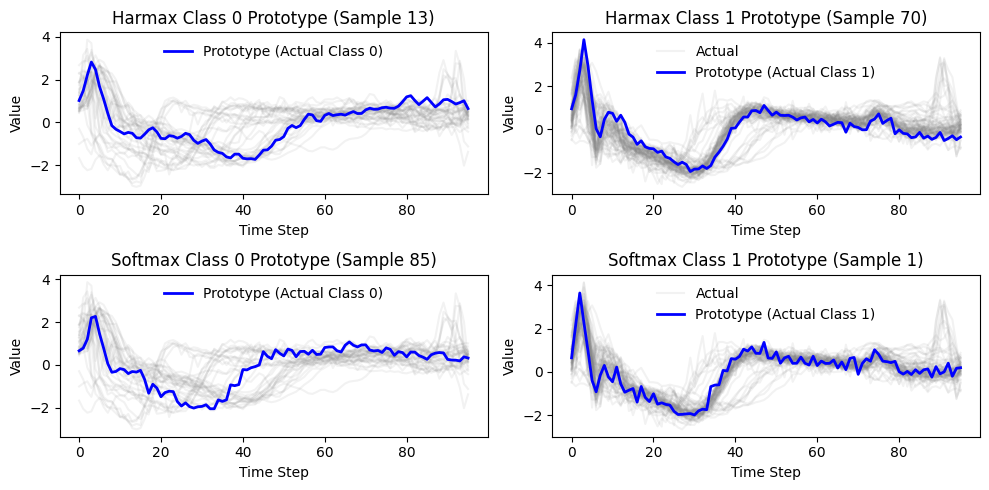

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

# Load the original test data (without z-scoring for interpretability)
data_dir = pathlib.Path('data')
Xte_raw, yte = load_ucr_txt(data_dir / 'ECG200_TEST.txt')

# Get the embeddings for the test set (already extracted in previous steps)
# harmax_embeddings: (100, 64), softmax_embeddings: (100, 64), labels: (100,)
# If not already extracted, you can use the get_embeddings function:
# harmax_embeddings, labels = get_embeddings(harmax_model, te_dl, device)
# softmax_embeddings, _ = get_embeddings(softmax_model, te_dl, device)

# Get class centers and weights
harmax_centres = harmax_model.head.centres.detach().cpu().numpy()  # (n_cls, 64)
softmax_weights = softmax_model.head.logits.weight.detach().cpu().numpy()  # (n_cls, 64)


def find_closest_samples(embeddings, centres, labels):
    closest_indices = []
    for j, centre in enumerate(centres):
        # only consider samples whose true label == j
        class_indices = np.where(labels == j)[0]
        class_embeds = embeddings[class_indices]
        dists = np.linalg.norm(class_embeds - centre, axis=1)
        # pick the overall-index of the nearest in‐class sample
        closest_idx = class_indices[np.argmin(dists)]
        closest_indices.append(closest_idx)
    return closest_indices


# 2) Change the calls to pass labels in:
harmax_closest_idx = find_closest_samples(harmax_embeddings, harmax_centres, labels)
softmax_closest_idx = find_closest_samples(softmax_embeddings, softmax_weights, labels)

# Create a 2x2 plot: Harmax prototypes (top), Softmax prototypes (bottom)
fig, axs = plt.subplots(2, 2, figsize=(10, 5))

# Plot Harmax prototypes with actual data
for i, idx in enumerate(harmax_closest_idx):
    # Plot all actual time series for this class (semi-transparent)
    class_label = i  # Use the intended class index (0 or 1) directly
    class_mask = labels == class_label
    for j in range(len(Xte_raw)):
        if class_mask[j]:
            axs[0, i].plot(Xte_raw[j], color='gray', alpha=0.1, label='Actual' if j == 0 else None)
    # Plot the prototype (bold)
    actual_class = labels[idx]  # For the label, show the actual class of the prototype
    axs[0, i].plot(Xte_raw[idx], label=f'Prototype (Actual Class {actual_class})', color='blue', linewidth=2)
    axs[0, i].set_title(f'Harmax Class {i} Prototype (Sample {idx})')
    axs[0, i].set_xlabel('Time Step')
    axs[0, i].set_ylabel('Value')
    axs[0, i].legend()

# Plot Softmax prototypes with actual data
for i, idx in enumerate(softmax_closest_idx):
    # Plot all actual time series for this class (semi-transparent)
    class_label = i  # Use the intended class index (0 or 1) directly
    class_mask = labels == class_label
    for j in range(len(Xte_raw)):
        if class_mask[j]:
            axs[1, i].plot(Xte_raw[j], color='gray', alpha=0.1, label='Actual' if j == 0 else None)
    # Plot the prototype (bold)
    actual_class = labels[idx]  # For the label, show the actual class of the prototype
    axs[1, i].plot(Xte_raw[idx], label=f'Prototype (Actual Class {actual_class})', color='blue', linewidth=2)
    axs[1, i].set_title(f'Softmax Class {i} Prototype (Sample {idx})')
    axs[1, i].set_xlabel('Time Step')
    axs[1, i].set_ylabel('Value')
    axs[1, i].legend()

# Adjust layout and save
plt.tight_layout()
plt.savefig('figures/ecg200_prototypes_with_actual_comparison_fixed.png', dpi=120)
plt.show()